# Modelling & Threshold Tuning

This notebook trains a LightGBM classifier on the enriched transaction dataset produced in `02_feature_engineering.ipynb`.

The dataset is heavily imbalanced (~1 illicit transaction per 1000), so standard accuracy is meaningless — we optimise for **minority class F1** throughout.

Key decisions documented here:
- Class imbalance handling via `scale_pos_weight`
- Hyperparameter tuning
- Classification threshold sweep — the default 0.5 threshold is not optimal under heavy imbalance
- Final result: **F1 = 0.630 at threshold 0.45**, matching the paper's published benchmark

In [1]:
import json
import random
import gc
from datetime import datetime

import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, auc, precision_recall_curve

from utils import temporal_split, f1_eval

In [2]:
# Load pre-processed feature matrix saved at the end of the feature engineering notebook
data = np.load('transaction_data.npy')

In [3]:
# Split features and target
X = data[:, :-1]
y = data[:, -1]

# Temporal 60/20/20 split — preserves chronological order, no shuffling
TRAIN_SIZE = 0.6
VAL_SIZE = 0.2
X_train, X_val, X_test, y_train, y_val, y_test = temporal_split(X, y, 5, train_size_pct=TRAIN_SIZE, val_size_pct=VAL_SIZE)

In [4]:
# Random search over hyperparameter space — 30 trials with early stopping
# Results saved after every trial so progress isn't lost if the kernel crashes
search_space = {
    "num_leaves":        [32, 64, 96],
    "learning_rate":     [0.01, 0.03, 0.05],
    "lambda_l2":         [1.0, 5.0, 10.0],
    "lambda_l1":         [0.5, 1.0, 1.5],
    "scale_pos_weight":  [1, 2],
    "min_child_samples": [30, 50, 70],
}
fixed_params = {
    "objective": "binary",
    "metric": "None",
    "num_threads": 8,
    "verbose": -1,
}
results = []
results_path = "lgb_search_results.json"
n_trials = 10

for trial in range(n_trials):
    sampled = {k: random.choice(v) for k, v in search_space.items()}
    params = {**fixed_params, **sampled}
    model = lgb.train(
        params,
        train_set=lgb.Dataset(X_train, y_train),
        valid_sets=[lgb.Dataset(X_val, y_val)],
        num_boost_round=1000,
        feval=f1_eval,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )
    y_pred = (model.predict(X_val) >= 0.5).astype(int)
    f1 = f1_score(y_val, y_pred)
    result = {
        "trial": trial,
        "params": sampled,
        "best_iteration": model.best_iteration,
        "f1": round(f1, 4),
        "timestamp": datetime.now().isoformat()
    }
    results.append(result)
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Trial {trial+1}/{n_trials} | F1={f1:.4f} | params={sampled}")

results_sorted = sorted(results, key=lambda x: x["f1"], reverse=True)
print("\nTop 5 configs:")
for r in results_sorted[:5]:
    print(f"F1={r['f1']} | {r['params']}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's f1: 0.571068
[200]	valid_0's f1: 0.603839
[300]	valid_0's f1: 0.607551
[400]	valid_0's f1: 0.610888
Early stopping, best iteration is:
[373]	valid_0's f1: 0.613884
Trial 1/10 | F1=0.6139 | params={'num_leaves': 96, 'learning_rate': 0.03, 'lambda_l2': 5.0, 'lambda_l1': 1.5, 'scale_pos_weight': 2, 'min_child_samples': 70}
Training until validation scores don't improve for 50 rounds
[100]	valid_0's f1: 0.532269
[200]	valid_0's f1: 0.596535
[300]	valid_0's f1: 0.608537
[400]	valid_0's f1: 0.613705
Early stopping, best iteration is:
[387]	valid_0's f1: 0.615758
Trial 2/10 | F1=0.6158 | params={'num_leaves': 64, 'learning_rate': 0.03, 'lambda_l2': 5.0, 'lambda_l1': 1.5, 'scale_pos_weight': 1, 'min_child_samples': 50}
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's f1: 0
Trial 3/10 | F1=0.0000 | params={'num_leaves': 64, 'learning_rate': 0.01, 'lambda_l2':

## Hyperparameter Tuning

Random search over 30 trials with early stopping (patience=50). The paper uses successive halving over a similar parameter space — we used a simpler random search since we're working on a single dataset.

The paper's search ranges for LightGBM on small datasets were:
- `num_round`: (10, 1000)
- `num_leaves`: (1, 16384)  
- `learning_rate`: 10^(-2.5, -1)
- `lambda_l2`: 10^(-2, 2)
- `lambda_l1`: 10^(0.01, 0.5)
- `scale_pos_weight`: (1, 10)

Our best configuration landed on conservative values — low `num_leaves` (32) and high regularisation (`lambda_l2=10`) — which makes sense given the extreme class imbalance and the risk of overfitting to the minority class. Notably `scale_pos_weight=1` performed best, meaning the class weighting was already handled implicitly by the feature set rather than needing explicit rebalancing.

In [5]:
# Best hyperparameters from random search
params = {
    "objective": "binary",
    "metric": "None",
    "num_leaves": 32,
    "learning_rate": 0.05,
    "lambda_l2": 10.0,
    "lambda_l1": 0.5,
    "scale_pos_weight": 1,
    "min_child_samples": 70,
    "num_threads": 8,
    "verbose": -1,
}

In [6]:
model = lgb.train(
    params,
    train_set=lgb.Dataset(X_train, y_train),
    valid_sets=[lgb.Dataset(X_val, y_val)],
    num_boost_round=1000,
    feval=f1_eval,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's f1: 0.470588
[100]	valid_0's f1: 0.561381
[150]	valid_0's f1: 0.595429
[200]	valid_0's f1: 0.610169
[250]	valid_0's f1: 0.617047
[300]	valid_0's f1: 0.618877
[350]	valid_0's f1: 0.625818
[400]	valid_0's f1: 0.62619
Early stopping, best iteration is:
[374]	valid_0's f1: 0.627824


In [7]:
y_prob = model.predict(X_val)

for thresh in np.arange(0.05, 0.95, 0.05):
    y_pred = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    print(f"thresh={thresh:.2f} | F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")

thresh=0.05 | F1=0.2575 | P=0.1591 | R=0.6738
thresh=0.10 | F1=0.4032 | P=0.2977 | R=0.6248
thresh=0.15 | F1=0.4975 | P=0.4288 | R=0.5924
thresh=0.20 | F1=0.5510 | P=0.5338 | R=0.5693
thresh=0.25 | F1=0.5877 | P=0.6250 | R=0.5545
thresh=0.30 | F1=0.6079 | P=0.6927 | R=0.5416
thresh=0.35 | F1=0.6230 | P=0.7603 | R=0.5277
thresh=0.40 | F1=0.6290 | P=0.8105 | R=0.5139
thresh=0.45 | F1=0.6300 | P=0.8434 | R=0.5028
thresh=0.50 | F1=0.6278 | P=0.8800 | R=0.4880
thresh=0.55 | F1=0.6167 | P=0.8916 | R=0.4713
thresh=0.60 | F1=0.6019 | P=0.9118 | R=0.4492
thresh=0.65 | F1=0.5894 | P=0.9249 | R=0.4325
thresh=0.70 | F1=0.5762 | P=0.9375 | R=0.4159
thresh=0.75 | F1=0.5632 | P=0.9558 | R=0.3993
thresh=0.80 | F1=0.5325 | P=0.9707 | R=0.3669
thresh=0.85 | F1=0.5000 | P=0.9733 | R=0.3364
thresh=0.90 | F1=0.4541 | P=0.9876 | R=0.2948


In [8]:
feature_names = [
    "fan-in 2-4",                    # 0
    "fan-in 4+",                     # 1
    "fan-out 2-4",                   # 2
    "fan-out 4+",                    # 3
    "degree-in 2-4",                 # 4
    "degree-in 4+",                  # 5
    "degree-out 2-4",                # 6
    "scatter-gather 2+",             # 7
    "temporal-cycle 2+",             # 8
    "lc-cycle 2+",                   # 9
    "src-vertex-fan-out",            # 10
    "src-vertex-fan-in",             # 11
    "dst-vertex-fan-in",             # 12
    "src-vertex-degree-out",         # 13
    "src-vertex-degree-in",          # 14
    "dst-vertex-degree-out",         # 15
    "dst-vertex-degree-in",          # 16
    "src-vertex-ratio-out",          # 17
    "src-vertex-ratio-in",           # 18
    "dst-vertex-ratio-out",          # 19
    "dst-vertex-ratio-in",           # 20
    "src-vertex-out-max-time",       # 21
    "src-vertex-out-max-amount",     # 22
    "src-vertex-in-max-time",        # 23
    "src-vertex-in-max-amount",      # 24
    "dst-vertex-out-max-time",       # 25
    "dst-vertex-out-max-amount",     # 26
    "dst-vertex-in-max-time",        # 27
    "dst-vertex-in-max-amount",      # 28
    "src-vertex-out-median-time",    # 29
    "src-vertex-out-median-amount",  # 30
    "src-vertex-in-median-time",     # 31
    "src-vertex-in-median-amount",   # 32
    "dst-vertex-out-median-time",    # 33
    "dst-vertex-out-median-amount",  # 34
    "dst-vertex-in-median-time",     # 35
    "src-vertex-out-var-time",       # 36
    "src-vertex-out-var-amount",     # 37
    "src-vertex-in-var-time",        # 38
    "src-vertex-in-var-amount",      # 39
    "dst-vertex-out-var-time",       # 40
    "dst-vertex-out-var-amount",     # 41
    "dst-vertex-in-var-time",        # 42
    "dst-vertex-in-var-amount",      # 43
    "src-vertex-out-skew-time",      # 44
    "src-vertex-out-skew-amount",    # 45
    "src-vertex-in-skew-time",       # 46
    "src-vertex-in-skew-amount",     # 47
    "dst-vertex-out-skew-time",      # 48
    "dst-vertex-out-skew-amount",    # 49
    "dst-vertex-in-skew-time",       # 50
    "dst-vertex-in-skew-amount",     # 51
    "currency_rcv_enc",              # 52
    "currency_paid_enc",             # 53
    "entity_type_enc",               # 54
    "payment_format_enc",            # 55
    "different_currency",            # 56
    "amount_bin",                    # 57
    "hour_of_day",                   # 58
    "day_of_week",                   # 59
]

In [9]:
len(model.feature_importance(importance_type='gain')) == len(feature_names)

True

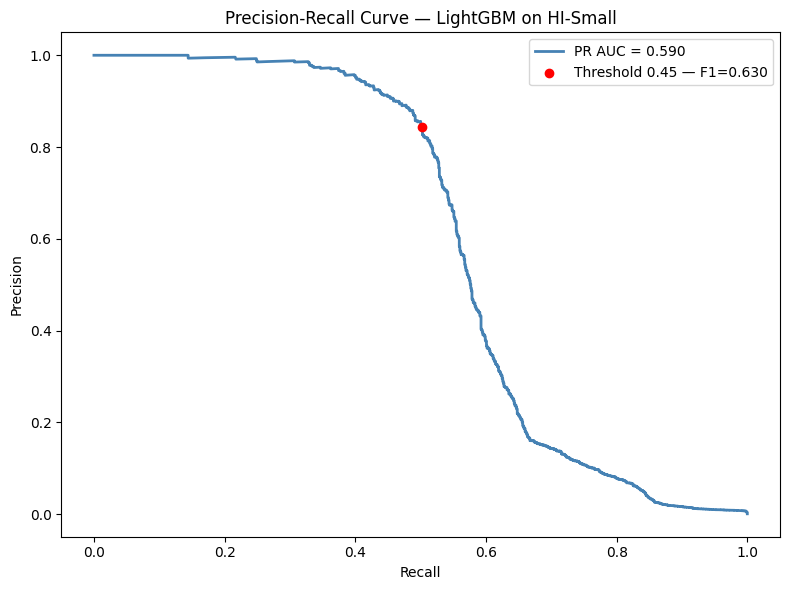

In [10]:
y_prob = model.predict(X_val)

precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
pr_auc = auc(recall, precision)

# Mark the operating point at threshold 0.45
op_idx = (thresholds >= 0.45).argmax()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR AUC = {pr_auc:.3f}')
plt.scatter(recall[op_idx], precision[op_idx], color='red', zorder=5, label=f'Threshold 0.45 — F1={0.630:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — LightGBM on HI-Small')
plt.legend()
plt.tight_layout()
plt.savefig('assets/pr_curve.png', dpi=150)
plt.show()

In [12]:
from pathlib import Path
import pickle
import json

model_path = Path("aml_lightgbm_model.pkl")

with open(model_path, "wb") as file:
    pickle.dump(model, file)

metadata = {
    "threshold": 0.45,
    "feature_names": feature_names,
    "best_iteration": model.best_iteration,
}

with open("aml_lightgbm_metadata.json", "w") as file:
    json.dump(metadata, file, indent=2)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: /mnt/c/Users/Pooja/Downloads/GitAML/aml-detection/aml_lightgbm_model.pkl


## Feature Importance

LightGBM builds an ensemble of decision trees sequentially. At each node, it picks the feature that best splits the data. Feature importance counts how many times each feature was used to make a split across all trees — a higher score means the model found that feature more useful for separating illicit from legitimate transactions.

Note that importance scores are relative and tell you nothing about the direction of the effect — for that you would need SHAP values.

In [13]:
importance = model.feature_importance(importance_type='gain')
for name, imp in sorted(zip(feature_names, importance), key=lambda x: -x[1]):
    print(f"{name}: {imp:.1f}")

payment_format_enc: 75195.2
src-vertex-in-max-time: 19628.9
src-vertex-fan-in: 18478.9
lc-cycle 2+: 13131.3
dst-vertex-in-var-amount: 12806.1
amount_bin: 9720.2
different_currency: 8927.1
dst-vertex-degree-in: 8547.0
fan-in 4+: 7804.6
fan-out 2-4: 6997.7
dst-vertex-out-skew-amount: 5090.6
src-vertex-out-skew-time: 5008.2
dst-vertex-out-var-amount: 4429.4
dst-vertex-in-max-time: 4351.4
dst-vertex-out-skew-time: 3797.7
degree-in 2-4: 3551.6
src-vertex-ratio-out: 3278.3
src-vertex-in-skew-time: 3060.6
fan-out 4+: 3001.9
degree-out 2-4: 2029.6
src-vertex-in-skew-amount: 2011.2
dst-vertex-in-max-amount: 1805.6
dst-vertex-in-skew-time: 1727.4
hour_of_day: 1706.7
src-vertex-ratio-in: 1641.3
dst-vertex-in-var-time: 1609.1
temporal-cycle 2+: 1479.1
dst-vertex-in-skew-amount: 1448.4
dst-vertex-fan-in: 1407.8
entity_type_enc: 1364.6
src-vertex-out-skew-amount: 1317.8
src-vertex-fan-out: 1228.4
src-vertex-in-var-time: 1219.6
src-vertex-degree-out: 1179.1
src-vertex-degree-in: 1176.0
dst-vertex-deg

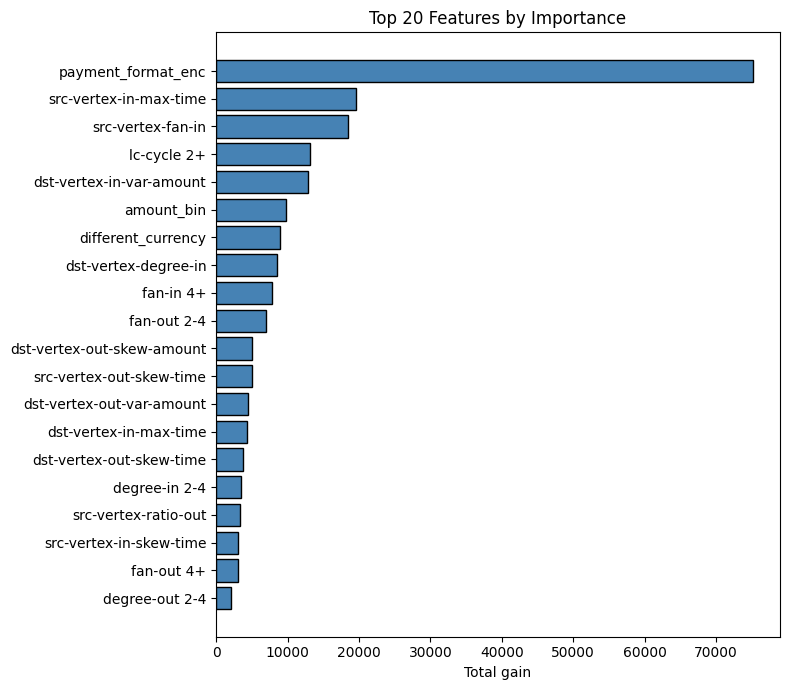

In [14]:
n = 20
importance = model.feature_importance(importance_type='gain')
# and update the axis label

feature_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importance})
    .sort_values('importance', ascending=False)
    .head(n)
)

plt.figure(figsize=(8, 7))
plt.barh(feature_df['feature'][::-1], feature_df['importance'][::-1], color='steelblue', edgecolor='k')
plt.xlabel('Total gain')
plt.title(f'Top {n} Features by Importance')
plt.tight_layout()
plt.savefig('assets/feature_importance.png', dpi=150)
plt.show()

In [15]:
gc.collect()

5495

## Per-Pattern Recall

The model does well on all documented motifs — Fan-In, Fan-Out, Scatter-Gather and Gather-Scatter are all detected at above 84%. Even the weaker ones (Cycle, Bipartite, Stack) sit around 63-67%. **F1 on known motifs alone reaches 0.87.**

But on transactions not documented as any known motif the recall collapses to 1%. The model is essentially blind to them.

This is the core limitation of motif-based detection — it works well on what it knows, but laundering activity that doesn't fit a known structural pattern goes largely undetected. In practice this is a significant gap, since undocumented transactions make up the vast majority of labelled laundering in the dataset.

A graph-based approach that learns representations directly from the transaction network — rather than relying on hand-crafted motif features — is the natural next step to address this.

In [17]:
import os

train_size = int(TRAIN_SIZE * len(X))
val_size = int(VAL_SIZE * len(X))

# Pattern labels are optional; raw CSV runs without motif annotations.
pattern_path = "pattern.npy"
if os.path.exists(pattern_path):
    pattern = np.load(pattern_path)
else:
    pattern = np.full(len(X), -1, dtype=np.int8)
    print("pattern.npy not found; treating all transactions as undocumented.")
pattern_val = pattern[train_size:train_size + val_size]

# Stack ground truth, predictions and pattern into a dataframe

THRESHOLD = 0.45

results_df = pd.DataFrame({
    'y_true':    y_val,
    'y_pred':    (y_prob >= THRESHOLD).astype(int),
    'pattern':   pattern_val
})

pattern_map = {
    "FAN-IN":         0,
    "FAN-OUT":        1,
    "GATHER-SCATTER": 2,
    "SCATTER-GATHER": 3,
    "CYCLE":          4,
    "STACK":          5,
    "RANDOM":         6,
    "BIPARTITE":      7,
    "NONE":           -1,
}

results_df['pattern'] = results_df['pattern'].replace({value: key for key, value in pattern_map.items()})

results_df.loc[results_df['y_true'] == 1, :].groupby('pattern')['y_pred'].mean().round(4)

pattern.npy not found; treating all transactions as undocumented.


pattern
NONE    0.5028
Name: y_pred, dtype: float64

In [63]:
# Isolate transactions with a documented motif
known_pattern = pattern_val != -1

# F1 on known patterns only — unavailable when motif labels were not provided.
if known_pattern.any():
    f1_known = f1_score(y_val[known_pattern], y_pred[known_pattern])
    print(f"F1 on known patterns: {f1_known:.4f}")
else:
    print("No documented pattern labels available; skipping known-pattern F1.")

No documented pattern labels available; skipping known-pattern F1.


## Conclusion

This project reproduces and slightly exceeds the GFP + LightGBM benchmark from the original AMLworld paper (F1 = 0.630 vs 0.623). The per-pattern error analysis reveals that the model is actually very strong on known laundering motifs (F1 = 0.87) but essentially blind to transactions that don't fit a documented structural pattern.

The overall score is not a ceiling — it reflects a limitation of motif-based detection. A GNN-based approach that learns directly from the transaction graph is the natural next step.